# genes filtering

- In order to run the adj matrix in the SpeakEasy algorithm we need to filter the genes by few ceriterias:

1. By genes variability.
2. By genes expression.

In [ ]:
import pandas as pd
import os
import rich as ri

tissues_files = {
    "AC": "/media/psylab-6028/DATA/Eden/CoExpression_ReProduction/ROSMAP_fixed_AC.csv",
    "MFBA9BA46": "/media/psylab-6028/DATA/Eden/CoExpression_ReProduction/ROSMAP_fixed_MFBA9BA46.csv",
    "PCGBA23": "/media/psylab-6028/DATA/Eden/CoExpression_ReProduction/ROSMAP_fixed_PCGBA23.csv"
}

tissues_dfs = pd.DataFrame()

for tissue, file_path in tissues_files.items():
    df = pd.read_csv(file_path)
    # Normalize the index column if present
    if 'Unnamed: 0' in df.columns:
        # treat as sample identifier
        df = df.rename(columns={'Unnamed: 0': 'sample_id'})
    else:
        # create a sample_id if none
        if 'sample_id' not in df.columns:
            df.insert(0, 'sample_id', range(len(df)))

    # Add tissue column
    df['tissue'] = tissue

    # Identify gene columns (exclude sample_id and tissue)
    gene_cols = [c for c in df.columns if c not in ('sample_id', 'tissue')]

    # Prefix gene columns with tissue
    prefixed_map = {g: f"{tissue}_{g}" for g in gene_cols}
    df = df.rename(columns=prefixed_map)

    tissues_dfs = pd.concat([tissues_dfs, df], axis=0, ignore_index=True)


In [ ]:
tissues_dfs

In [ ]:
import pandas as pd
import numpy as np
import rich as ri

# 1. Drop the redundant index column if present
if 'sample_id' in tissues_dfs.columns:
    # If it's really just a row index, drop it
    if tissues_dfs['sample_id'].dtype == object or tissues_dfs['sample_id'].is_monotonic_increasing:
        tissues_dfs = tissues_dfs.drop(columns=['sample_id'])

# 2. Identify non-gene columns to exclude
EXCLUDE = {'tissue'}

# 3. Coerce remaining columns to numeric (silently turning non-numeric to NaN)
gene_cols = [c for c in tissues_dfs.columns if c not in EXCLUDE]
tissues_dfs[gene_cols] = tissues_dfs[gene_cols].apply(lambda s: pd.to_numeric(s, errors='coerce'))

# 4. Keep only numeric columns
numeric_gene_cols = [c for c in gene_cols if pd.api.types.is_numeric_dtype(tissues_dfs[c])]

ri.print(f"[bold green]Numeric gene columns:[/bold green] {len(numeric_gene_cols)}")

# 5. Vectorized percentile calculation (much faster than loop)
def gene_percentiles(df: pd.DataFrame, q_percent: int):
    q = q_percent / 100.0
    return df[numeric_gene_cols].quantile(q).to_dict()

p1 = gene_percentiles(tissues_dfs, 1)
p2 = gene_percentiles(tissues_dfs, 2)
p5 = gene_percentiles(tissues_dfs, 5)
p10 = gene_percentiles(tissues_dfs, 10)
p15 = gene_percentiles(tissues_dfs, 15)
p20 = gene_percentiles(tissues_dfs, 20)
p25 = gene_percentiles(tissues_dfs, 25)
ri.print("[bold green]the number of genes under each percentile is:[/bold green]")
ri.print(f"[bold green]1st percentile n of genes:[/bold green] {len([v for v in p1.values() if v >= 0])}")
ri.print(f"[bold green]2nd percentile n of genes:[/bold green] {len([v for v in p2.values() if v >= 0])}")
ri.print(f"[bold green]5th percentile n of genes:[/bold green] {len([v for v in p5.values() if v >= 0])}")
ri.print(f"[bold green]10th percentile n of genes:[/bold green] {len([v for v in p10.values() if v >= 0])}")
ri.print(f"[bold green]15th percentile n of genes:[/bold green] {len([v for v in p15.values() if v >= 0])}")
ri.print(f"[bold green]20th percentile n of genes:[/bold green] {len([v for v in p20.values() if v >= 0])}")
ri.print(f"[bold green]25th percentile n of genes:[/bold green] {len([v for v in p25.values() if v >= 0])}")

In [ ]:
def filter_low_by_sample_percentile(df, numeric_gene_cols, percentile=20.0, frac_below=0.8):
    sample_cutoffs = df[numeric_gene_cols].quantile(percentile / 100.0, axis=1)
    low_mask = df[numeric_gene_cols].lt(sample_cutoffs, axis=0)
    below_share = low_mask.mean(axis=0)
    dropped = below_share[below_share >= frac_below].index
    return df.drop(columns=dropped), dropped, sample_cutoffs


percentile  dropped_genes  remaining_genes
0            0              0            51918
1            2           1120            50798
2            4           2245            49673
3            6           3361            48557
4            8           4404            47514
5           10           5494            46424
6           12           6586            45332
7           14           7677            44241
8           16           8735            43183
9           18           9765            42153
10          20          10832            41086
11          22          11975            39943
12          24          13044            38874
13          26          14090            37828
14          28          15124            36794
15          30          16185            35733
16          32          17280            34638
17          34          18357            33561
18          36          19402            32516
19          38          20438            31480
20          40          21527            30391
21          42          22569            29349
22          44          23612            28306
23          46          24639            27279
24          48          25689            26229
25          50          26752            25166
26          52          27787            24131
27          54          28851            23067
28          56          29893            22025
29          58          30934            20984
30          60          31959            19959
31          62          33019            18899
32          64          34005            17913
33          66          35014            16904
34          68          36031            15887
35          70          37091            14827
36          72          38115            13803
37          74          39144            12774
38          76          40132            11786
39          78          41129            10789
40          80          42136             9782
41          82          43159             8759
42          84          44181             7737
43          86          45157             6761
44          88          46152             5766
45          90          47140             4778
46          92          48131             3787
47          94          49123             2795
48          96          50085             1833
49          98          51035              883
50         100          51918                0

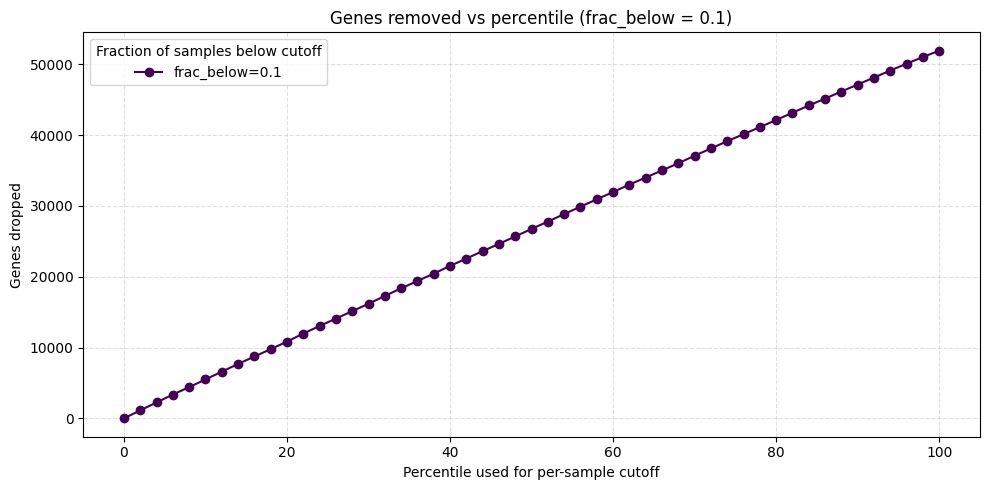

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
97           92          47513             4405
98           94          48603             3315
99           96          49695             2223
100          98          50789             1129
101         100          51914                4

[102 rows x 3 columns]

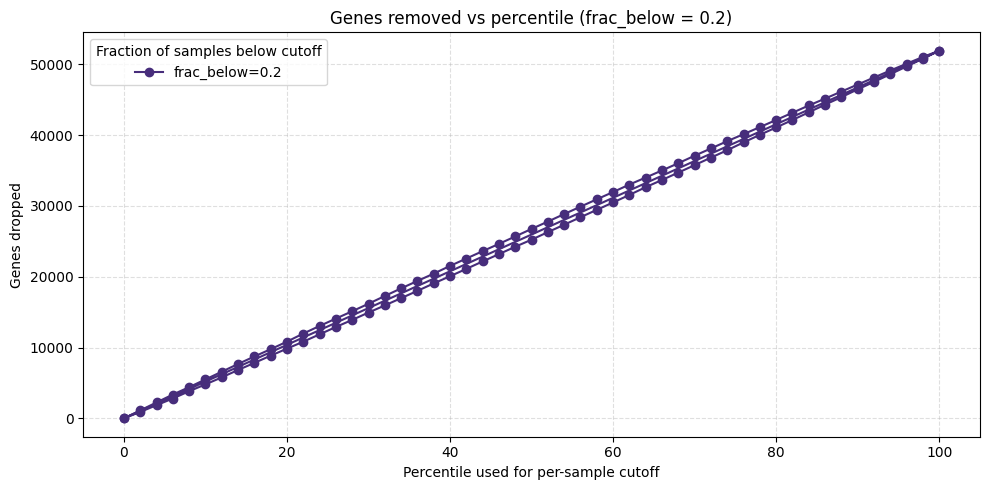

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
148          92          15848            36070
149          94          16204            35714
150          96          16573            35345
151          98          16931            34987
152         100          17305            34613

[153 rows x 3 columns]

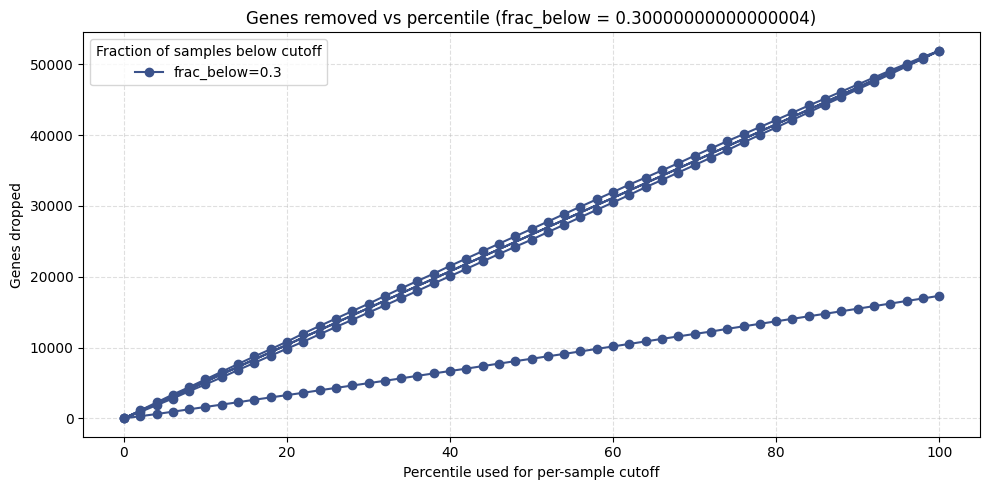

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
199          92          15640            36278
200          94          16034            35884
201          96          16441            35477
202          98          16862            35056
203         100          17303            34615

[204 rows x 3 columns]

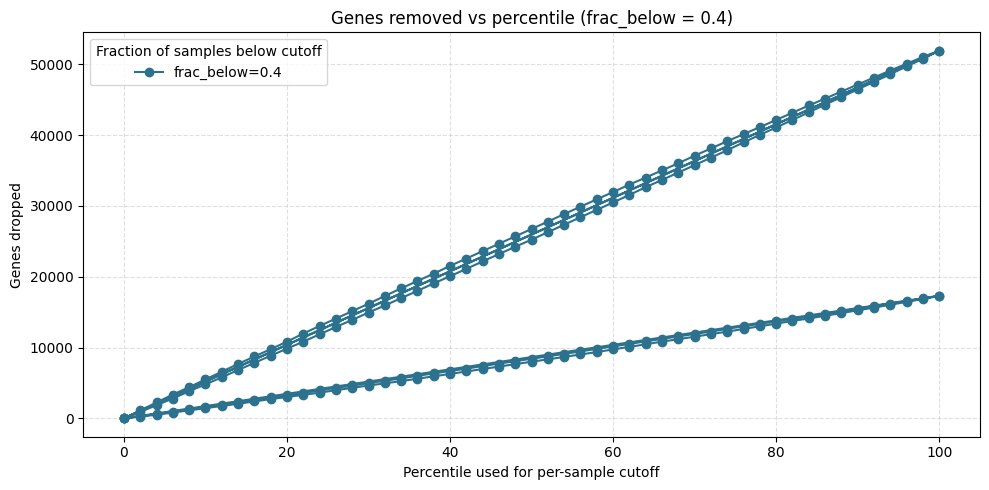

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
250          92              0            51918
251          94              0            51918
252          96              0            51918
253          98              0            51918
254         100              0            51918

[255 rows x 3 columns]

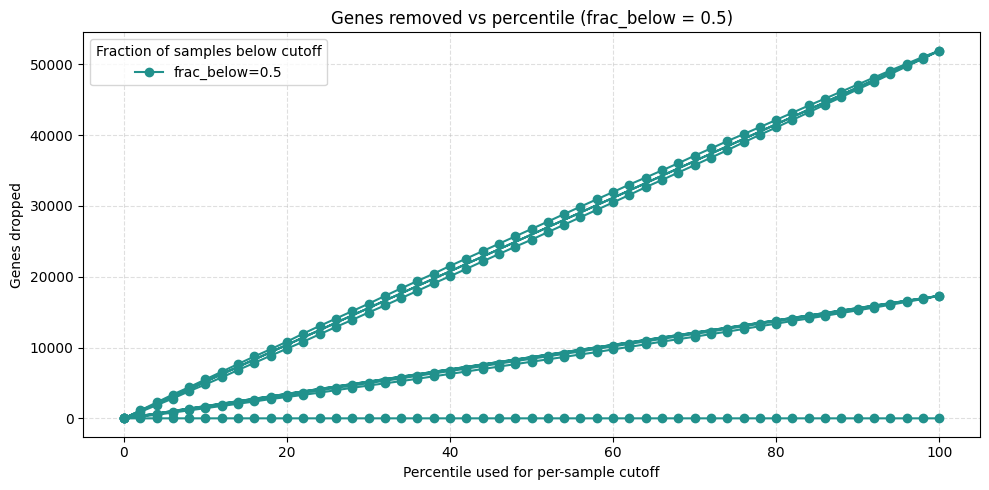

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
301          92              0            51918
302          94              0            51918
303          96              0            51918
304          98              0            51918
305         100              0            51918

[306 rows x 3 columns]

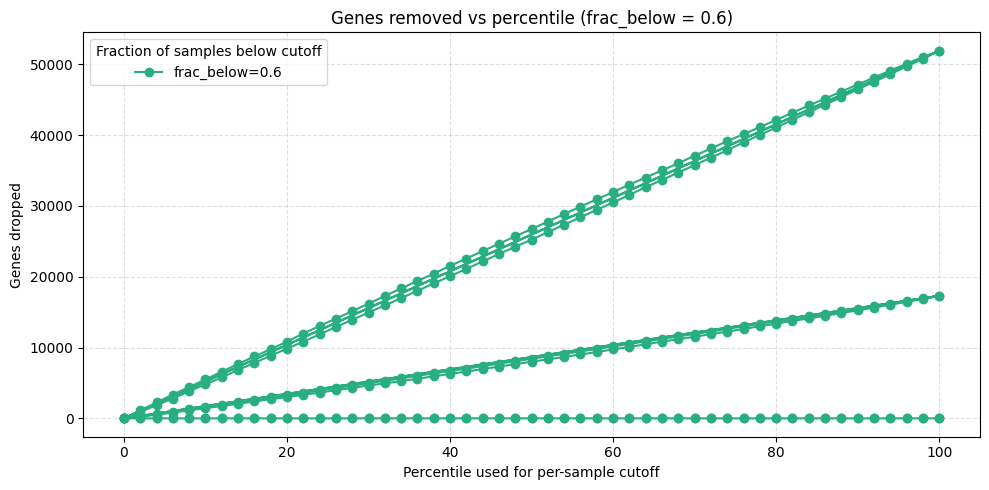

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
352          92              0            51918
353          94              0            51918
354          96              0            51918
355          98              0            51918
356         100              0            51918

[357 rows x 3 columns]

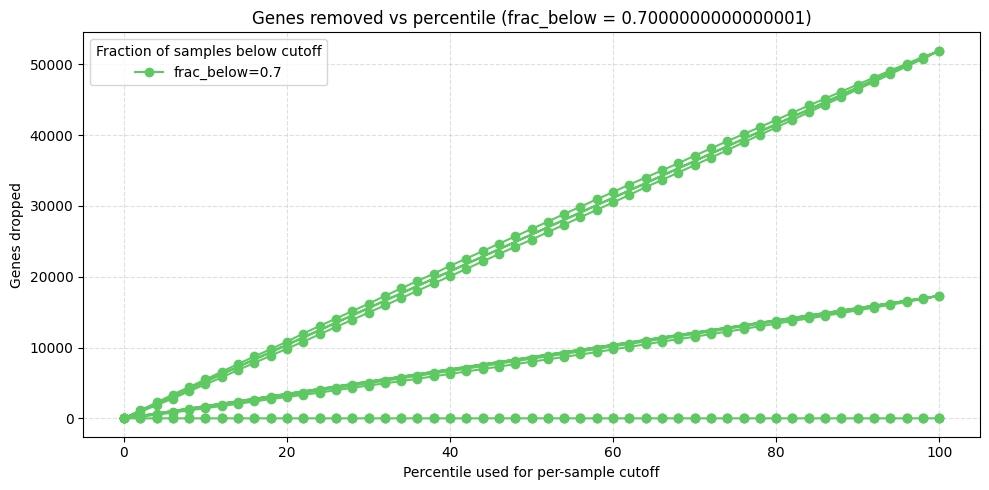

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
403          92              0            51918
404          94              0            51918
405          96              0            51918
406          98              0            51918
407         100              0            51918

[408 rows x 3 columns]

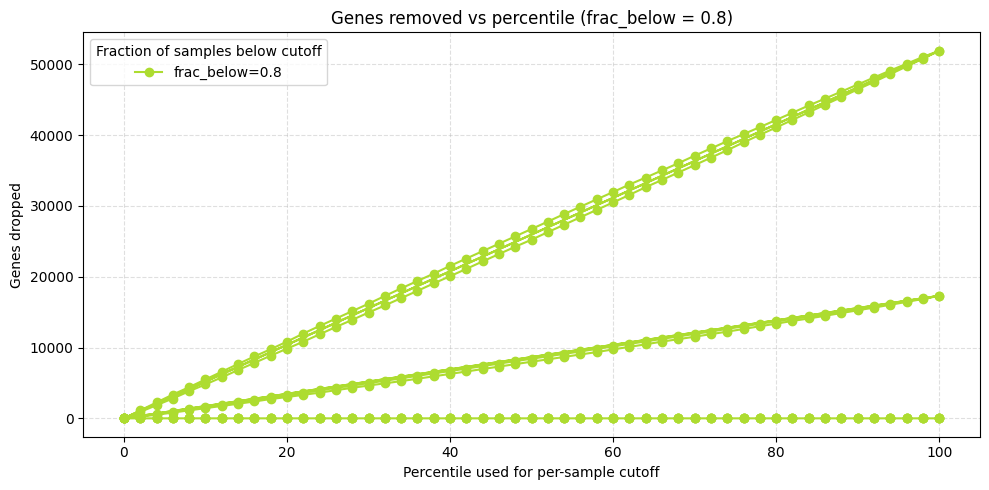

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
454          92              0            51918
455          94              0            51918
456          96              0            51918
457          98              0            51918
458         100              0            51918

[459 rows x 3 columns]

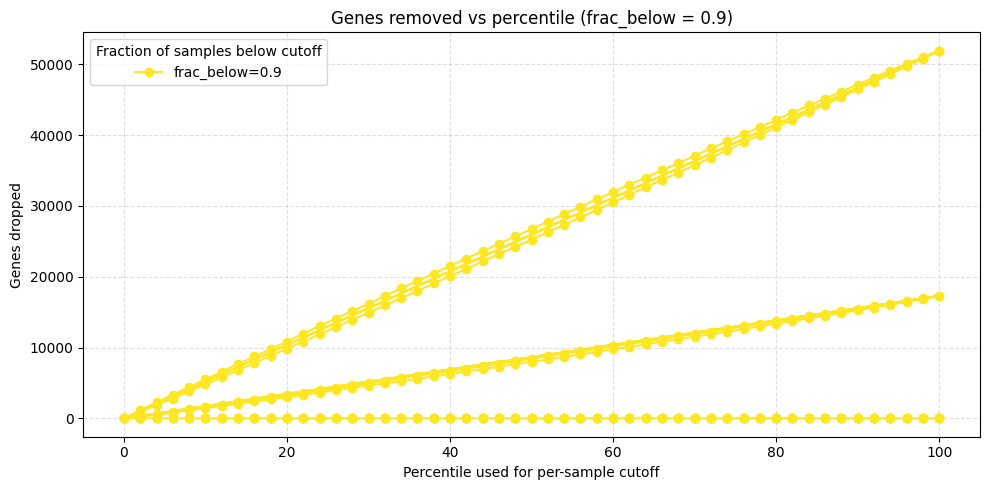

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

percentiles = np.arange(0, 101, 2)  # from 0 to 100 inclusive, step 5
fracs_below = np.arange(0.1, 1.0, 0.1)  # from 0.1 to 0.9 inclusive, step 0.1
colors = plt.cm.viridis(np.linspace(0, 1, len(fracs_below)))
drop_stats = []
for frac_below in fracs_below:
    for perc in percentiles:
        _, dropped_genes, sample_cutoffs = filter_low_by_sample_percentile(
        tissues_dfs,
        numeric_gene_cols,
        percentile=perc,
        frac_below=frac_below,
        )
        drop_stats.append(
            {
                "percentile": perc,
                "dropped_genes": len(dropped_genes),
                "remaining_genes": len(numeric_gene_cols) - len(dropped_genes),
            }
        )

    drop_df = pd.DataFrame(drop_stats)
    ri.print(drop_df)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(drop_df["percentile"], drop_df["dropped_genes"], marker="o", color=colors[int(frac_below*10)-1], label=f"frac_below={frac_below:.1f}")
    ax.legend(title="Fraction of samples below cutoff")
    ax.set_xlabel("Percentile used for per-sample cutoff")
    ax.set_ylabel("Genes dropped")
    ax.set_title(f"Genes removed vs percentile (frac_below = {frac_below})")
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd

# variance across samples for every gene column
gene_variance = tissues_dfs[numeric_gene_cols].var(axis=0, ddof=1)

# look at the lowest-variance genes
low_var_genes = gene_variance.sort_values().head(20)
ri.print(low_var_genes)

# show a quick summary of the variance distribution
ri.print(gene_variance.describe())


AC_ENSG00000092148.12         0.004679
PCGBA23_ENSG00000092148.12    0.006228
AC_ENSG00000119396.10         0.006294
PCGBA23_ENSG00000111540.15    0.006631
AC_ENSG00000121741.16         0.006670
AC_ENSG00000111540.15         0.006725
AC_ENSG00000174903.15         0.007052
AC_ENSG00000134644.15         0.007085
AC_ENSG00000131508.15         0.007170
AC_ENSG00000116030.16         0.007428
AC_ENSG00000174231.16         0.007441
AC_ENSG00000009307.15         0.007496
AC_ENSG00000116539.12         0.007533
AC_ENSG00000166266.13         0.007541
AC_ENSG00000101266.17         0.007585
AC_ENSG00000166181.12         0.007758
AC_ENSG00000126698.10         0.007760
AC_ENSG00000102753.9          0.007918
PCGBA23_ENSG00000086758.15    0.008089
AC_ENSG00000196419.12         0.008281
dtype: float64

count    51918.000000
mean         0.252073
std          0.456370
min          0.004679
25%          0.048015
50%          0.111376
75%          0.298331
max         21.409772
dtype: float64

In [ ]:
plot_gene_percentile_hist_by_mean(tissues_dfs, numeric_gene_cols)

In [1]:
source("/media/psylab-6028/DATA/Eden/CoExpression_ReProduction/old_scripts/ClusteringBuilding.R")

Loading required package: dynamicTreeCut

Loading required package: fastcluster


Attaching package: ‘fastcluster’


The following object is masked from ‘package:stats’:

    hclust





Attaching package: ‘WGCNA’


The following object is masked from ‘package:stats’:

    cor




Allowing multi-threading with up to 32 threads.
Allowing multi-threading with up to 32 threads.


In [3]:
rosmap_files <- c(
    "/media/psylab-6028/DATA/Eden/CoExpression_ReProduction/ROSMAP_fixed_AC.csv",
    "/media/psylab-6028/DATA/Eden/CoExpression_ReProduction/ROSMAP_fixed_MFBA9BA46.csv",
    "/media/psylab-6028/DATA/Eden/CoExpression_ReProduction/ROSMAP_fixed_PCGBA23.csv"
)

tissues = c("AC","MFBA9BA46","PCGBA23")

In [4]:
XWGCNA_Clusters_autoBeta(
    tissue_names = tissues,
    tissue_expr_file_names = rosmap_files,
    sd_quantile = 0.5,
    max_genes_per_tissue = 999999,     
    out_prefix = "xwgcna_rosmap_constBeta_CT2_TS3_filtered_var0.5",
    auto_beta = FALSE,
    plot_beta_curves = TRUE,
    blockwise_TOM = TRUE,
    TS_power = 3,
    CT_power = 2,
    group = "xwgcna_rosmap_constBeta_CT2_TS3_filtered_var0.5",
    beta_method = "wgcna_new",
    save_intermediates = TRUE,
    wgcna_powerVector = seq(0.5, 20, length.out = 20),
    ct_fisher = FALSE,
    ct_fisher_scheme = "to_ref",
    ct_fisher_Nref = "max",
    ct_too_few_action = "zero",
    adj_type = "new"
)

Using constant β values.

Adjacency: 3.000000 tissues, up to 999999.000000 genes/tissue (sd_quantile=0.50).

Computing TOM (this may take a while) ...

Computing TOM from adjacency matrix...

Number of genes: 25959; Number of samples: 25959

Processing block 1 to 2000

Finished block 1 to 2000

Processing block 2001 to 4000

Finished block 2001 to 4000

Processing block 4001 to 6000

Finished block 4001 to 6000

Processing block 6001 to 8000

Finished block 6001 to 8000

Processing block 8001 to 10000

Finished block 8001 to 10000

Processing block 10001 to 12000

Finished block 10001 to 12000

Processing block 12001 to 14000

Finished block 12001 to 14000

Processing block 14001 to 16000

Finished block 14001 to 16000

Processing block 16001 to 18000

Finished block 16001 to 18000

Processing block 18001 to 20000

Finished block 18001 to 20000

Processing block 20001 to 22000

Finished block 20001 to 22000

Processing block 22001 to 24000

Finished block 22001 to 24000

Processing blo

Cluster ID,Tissue,Gene Symbol,stringAsFactors
<chr>,<chr>,<chr>,<chr>
1,AC,ENSG00000006047.12,FALSE
1,AC,ENSG00000006611.15,FALSE
1,AC,ENSG00000026950.16,FALSE
1,AC,ENSG00000049192.14,FALSE
1,AC,ENSG00000060656.19,FALSE
1,AC,ENSG00000064309.14,FALSE
1,AC,ENSG00000068001.13,FALSE
1,AC,ENSG00000074181.8,FALSE
1,AC,ENSG00000080573.6,FALSE


In [5]:
XWGCNA_Clusters_autoBeta(
    tissue_names = tissues,
    tissue_expr_file_names = rosmap_files,
    sd_quantile = 0.8,
    max_genes_per_tissue = 999999,     
    out_prefix = "xwgcna_rosmap_constBeta_CT2_TS3_filtered_var0.8",
    auto_beta = FALSE,
    plot_beta_curves = TRUE,
    blockwise_TOM = TRUE,
    TS_power = 3,
    CT_power = 2,
    group = "xwgcna_rosmap_constBeta_CT2_TS3_filtered_var0.8",
    beta_method = "wgcna_new",
    save_intermediates = TRUE,
    wgcna_powerVector = seq(0.5, 20, length.out = 20),
    ct_fisher = FALSE,
    ct_fisher_scheme = "to_ref",
    ct_fisher_Nref = "max",
    ct_too_few_action = "zero",
    adj_type = "new"
)

Using constant β values.

Adjacency: 3.000000 tissues, up to 999999.000000 genes/tissue (sd_quantile=0.80).

Computing TOM (this may take a while) ...

Computing TOM from adjacency matrix...

Number of genes: 10386; Number of samples: 10386

Processing block 1 to 2000

Finished block 1 to 2000

Processing block 2001 to 4000

Finished block 2001 to 4000

Processing block 4001 to 6000

Finished block 4001 to 6000

Processing block 6001 to 8000

Finished block 6001 to 8000

Processing block 8001 to 10000

Finished block 8001 to 10000

Processing block 10001 to 10386

Finished block 10001 to 10386

TOM calculation done.

Clustering on TOM...

Plot heatmap6615

Warning message in plot.window(...):
“"moduleColors" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"moduleColors" is not a graphical parameter”
Warning message in title(...):
“"moduleColors" is not a graphical parameter”


Cluster ID,Tissue,Gene Symbol,stringAsFactors
<chr>,<chr>,<chr>,<chr>
1,AC,ENSG00000000003.14,FALSE
1,AC,ENSG00000002586.18,FALSE
1,AC,ENSG00000002586.18,FALSE
1,AC,ENSG00000004838.13,FALSE
1,AC,ENSG00000006016.10,FALSE
1,AC,ENSG00000007174.17,FALSE
1,AC,ENSG00000007516.13,FALSE
1,AC,ENSG00000008226.19,FALSE
1,AC,ENSG00000026559.13,FALSE


In [9]:
XWGCNA_Clusters_autoBeta(
    tissue_names = tissues,
    tissue_expr_file_names = rosmap_files,
    sd_quantile = 0.2,
    max_genes_per_tissue = 999999,     
    out_prefix = "xwgcna_rosmap_constBeta_CT2_TS3_filtered_var0.2",
    auto_beta = FALSE,
    plot_beta_curves = TRUE,
    blockwise_TOM = TRUE,
    TS_power = 3,
    CT_power = 2,
    group = "xwgcna_rosmap_constBeta_CT2_TS3_filtered_var0.2",
    beta_method = "wgcna_new",
    save_intermediates = TRUE,
    wgcna_powerVector = seq(0.5, 20, length.out = 20),
    ct_fisher = FALSE,
    ct_fisher_scheme = "to_ref",
    ct_fisher_Nref = "max",
    ct_too_few_action = "zero",
    adj_type = "new"
)

Using constant β values.

Adjacency: 3.000000 tissues, up to 999999.000000 genes/tissue (sd_quantile=0.20).



Computing TOM (this may take a while) ...

Computing TOM from adjacency matrix...

Number of genes: 41535; Number of samples: 41535

Processing block 1 to 2000

Finished block 1 to 2000

Processing block 2001 to 4000

Finished block 2001 to 4000

Processing block 4001 to 6000

Finished block 4001 to 6000

Processing block 6001 to 8000

Finished block 6001 to 8000

Processing block 8001 to 10000

Finished block 8001 to 10000

Processing block 10001 to 12000

Finished block 10001 to 12000

Processing block 12001 to 14000

Finished block 12001 to 14000

Processing block 14001 to 16000

Finished block 14001 to 16000

Processing block 16001 to 18000

Finished block 16001 to 18000

Processing block 18001 to 20000

Finished block 18001 to 20000

Processing block 20001 to 22000

Finished block 20001 to 22000

Processing block 22001 to 24000

Finished block 22001 to 24000

Processing block 24001 to 26000

Finished block 24001 to 26000

Processing block 26001 to 28000

Finished block 26001 to 28

Cluster ID,Tissue,Gene Symbol,stringAsFactors
<chr>,<chr>,<chr>,<chr>
1,AC,ENSG00000006025.11,FALSE
1,AC,ENSG00000010030.13,FALSE
1,AC,ENSG00000018236.14,FALSE
1,AC,ENSG00000058866.14,FALSE
1,AC,ENSG00000065485.19,FALSE
1,AC,ENSG00000071243.15,FALSE
1,AC,ENSG00000072210.18,FALSE
1,AC,ENSG00000074416.13,FALSE
1,AC,ENSG00000077684.15,FALSE


In [ ]:
XWGCNA_Clusters_autoBeta(
    tissue_names = tissues,
    tissue_expr_file_names = rosmap_files,
    sd_quantile = 0.1,
    max_genes_per_tissue = 999999,     
    out_prefix = "xwgcna_rosmap_constBeta_CT2_TS3_filtered_var0.1",
    auto_beta = FALSE,
    plot_beta_curves = TRUE,
    blockwise_TOM = TRUE,
    TS_power = 3,
    CT_power = 2,
    group = "xwgcna_rosmap_constBeta_CT2_TS3_filtered_var0.1",
    beta_method = "wgcna_new",
    save_intermediates = TRUE,
    wgcna_powerVector = seq(0.5, 20, length.out = 20),
    ct_fisher = FALSE,
    ct_fisher_scheme = "to_ref",
    ct_fisher_Nref = "max",
    ct_too_few_action = "zero",
    adj_type = "new"
)

In [10]:
adj_matrix <- readRDS("/media/psylab-6028/DATA/Eden/CoExpression_ReProduction/nbs/xwgcna_rosmap_constBeta_CT2_TS3_filtered_var0.2_adjacency.rds")
write.csv(adj_matrix, file="/media/psylab-6028/DATA/Eden/CoExpression_ReProduction/nbs/xwgcna_rosmap_constBeta_CT2_TS3_filtered_var0.2_adjacency.csv", row.names=TRUE)

percentile  dropped_genes  remaining_genes
0            0              0            51918
1            2           1120            50798
2            4           2245            49673
3            6           3361            48557
4            8           4404            47514
5           10           5494            46424
6           12           6586            45332
7           14           7677            44241
8           16           8735            43183
9           18           9765            42153
10          20          10832            41086
11          22          11975            39943
12          24          13044            38874
13          26          14090            37828
14          28          15124            36794
15          30          16185            35733
16          32          17280            34638
17          34          18357            33561
18          36          19402            32516
19          38          20438            31480
20          40          21527            30391
21          42          22569            29349
22          44          23612            28306
23          46          24639            27279
24          48          25689            26229
25          50          26752            25166
26          52          27787            24131
27          54          28851            23067
28          56          29893            22025
29          58          30934            20984
30          60          31959            19959
31          62          33019            18899
32          64          34005            17913
33          66          35014            16904
34          68          36031            15887
35          70          37091            14827
36          72          38115            13803
37          74          39144            12774
38          76          40132            11786
39          78          41129            10789
40          80          42136             9782
41          82          43159             8759
42          84          44181             7737
43          86          45157             6761
44          88          46152             5766
45          90          47140             4778
46          92          48131             3787
47          94          49123             2795
48          96          50085             1833
49          98          51035              883
50         100          51918                0

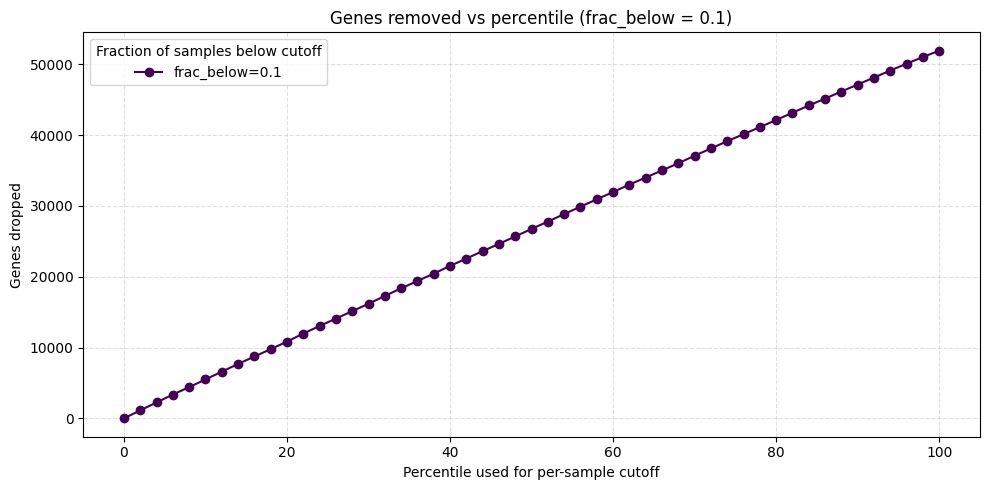

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
97           92          47513             4405
98           94          48603             3315
99           96          49695             2223
100          98          50789             1129
101         100          51914                4

[102 rows x 3 columns]

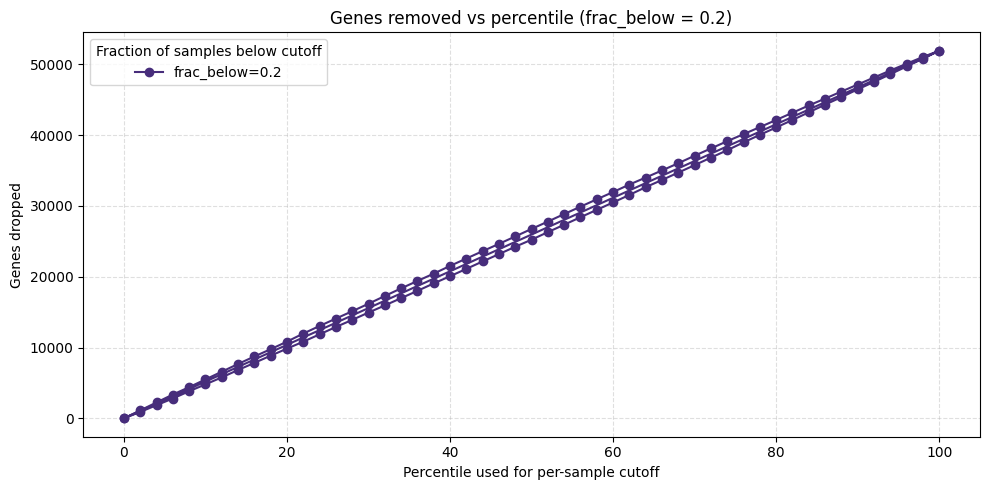

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
148          92          15848            36070
149          94          16204            35714
150          96          16573            35345
151          98          16931            34987
152         100          17305            34613

[153 rows x 3 columns]

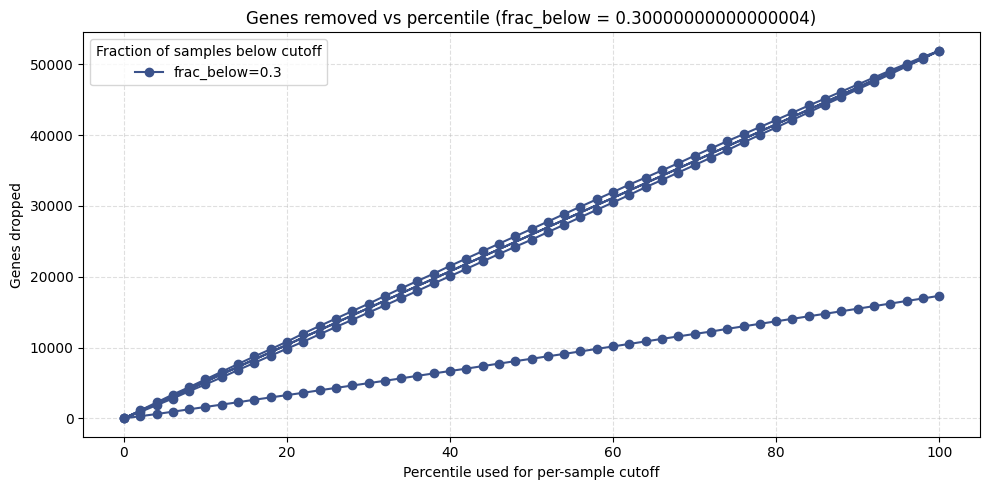

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
199          92          15640            36278
200          94          16034            35884
201          96          16441            35477
202          98          16862            35056
203         100          17303            34615

[204 rows x 3 columns]

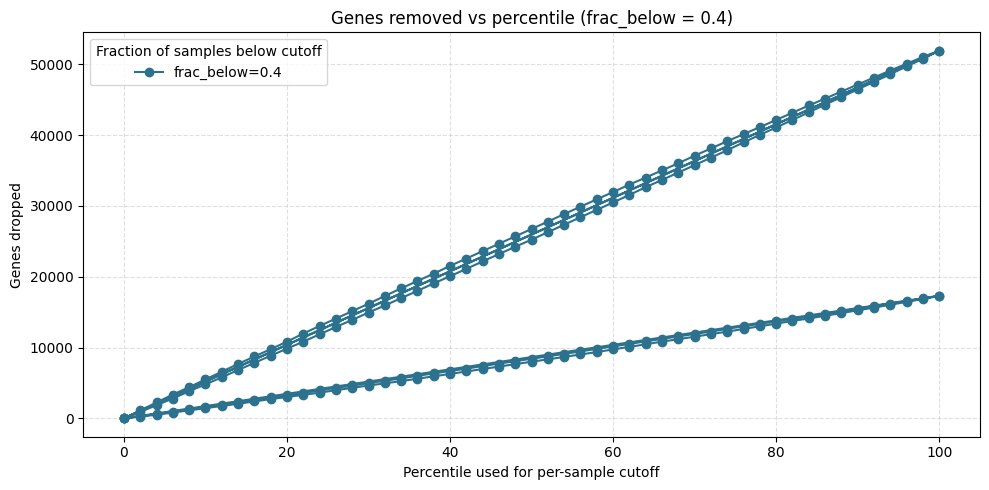

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
250          92              0            51918
251          94              0            51918
252          96              0            51918
253          98              0            51918
254         100              0            51918

[255 rows x 3 columns]

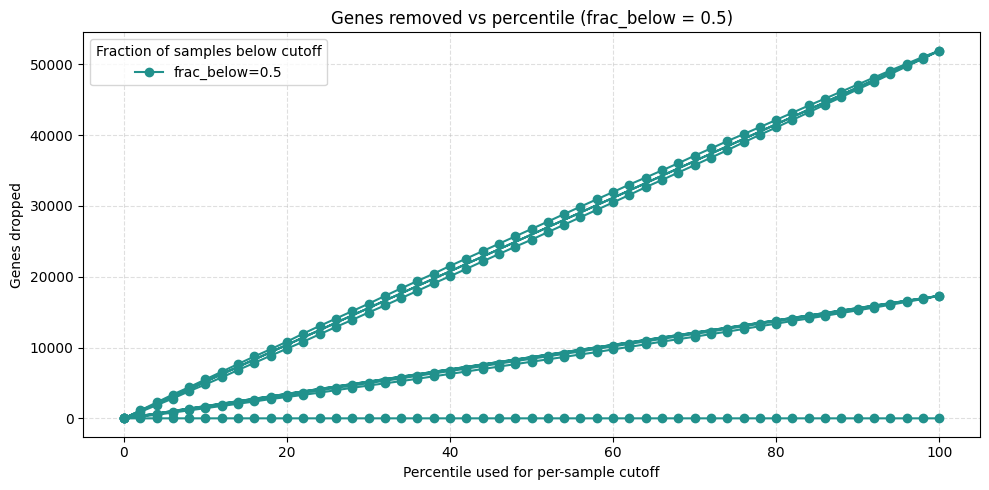

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
301          92              0            51918
302          94              0            51918
303          96              0            51918
304          98              0            51918
305         100              0            51918

[306 rows x 3 columns]

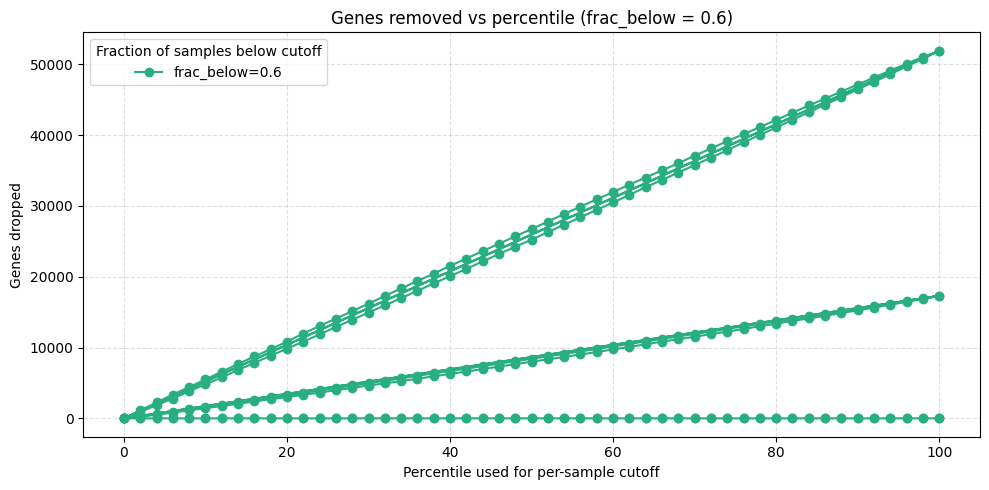

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
352          92              0            51918
353          94              0            51918
354          96              0            51918
355          98              0            51918
356         100              0            51918

[357 rows x 3 columns]

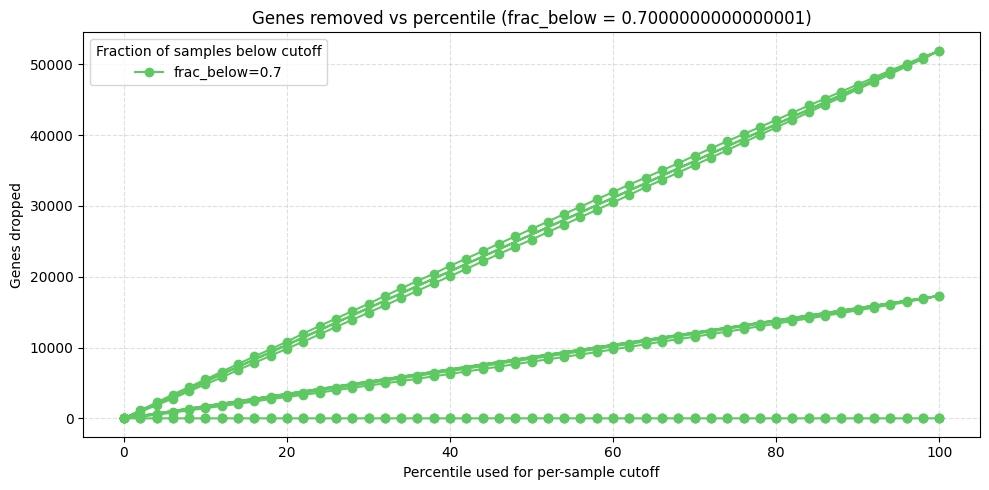

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
403          92              0            51918
404          94              0            51918
405          96              0            51918
406          98              0            51918
407         100              0            51918

[408 rows x 3 columns]

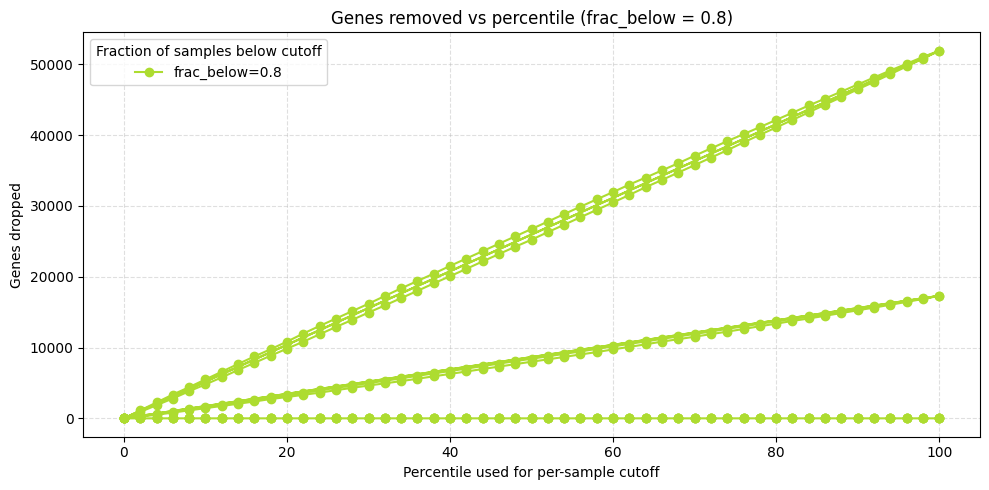

percentile  dropped_genes  remaining_genes
0             0              0            51918
1             2           1120            50798
2             4           2245            49673
3             6           3361            48557
4             8           4404            47514
..          ...            ...              ...
454          92              0            51918
455          94              0            51918
456          96              0            51918
457          98              0            51918
458         100              0            51918

[459 rows x 3 columns]

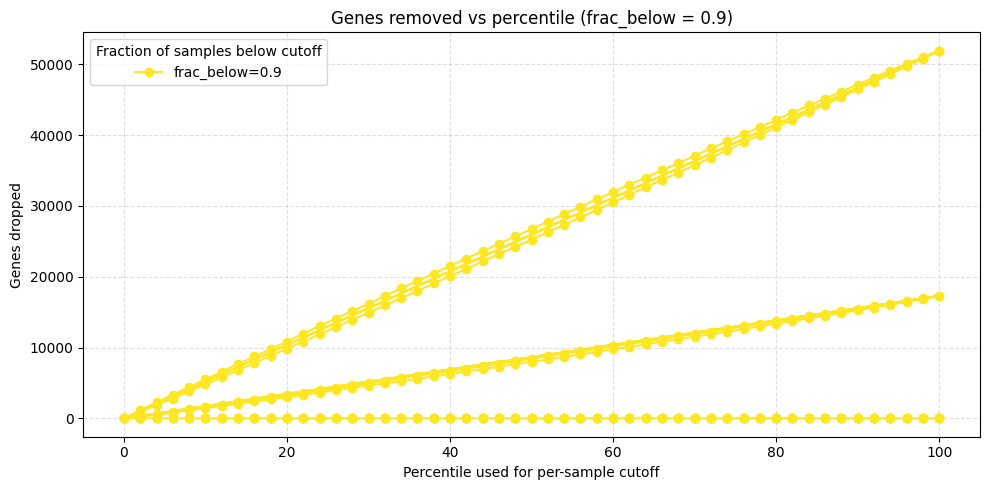

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

percentiles = np.arange(0, 101, 2)  # from 0 to 100 inclusive, step 5
fracs_below = np.arange(0.1, 1.0, 0.1)  # from 0.1 to 0.9 inclusive, step 0.1
colors = plt.cm.viridis(np.linspace(0, 1, len(fracs_below)))
drop_stats = []
for frac_below in fracs_below:
    for perc in percentiles:
        _, dropped_genes, sample_cutoffs = filter_low_by_sample_percentile(
        tissues_dfs,
        numeric_gene_cols,
        percentile=perc,
        frac_below=frac_below,
        )
        drop_stats.append(
            {
                "percentile": perc,
                "dropped_genes": len(dropped_genes),
                "remaining_genes": len(numeric_gene_cols) - len(dropped_genes),
            }
        )

    drop_df = pd.DataFrame(drop_stats)
    ri.print(drop_df)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(drop_df["percentile"], drop_df["dropped_genes"], marker="o", color=colors[int(frac_below*10)-1], label=f"frac_below={frac_below:.1f}")
    ax.legend(title="Fraction of samples below cutoff")
    ax.set_xlabel("Percentile used for per-sample cutoff")
    ax.set_ylabel("Genes dropped")
    ax.set_title(f"Genes removed vs percentile (frac_below = {frac_below})")
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
